# 3.6. Kết quả Thực nghiệm Phân loại Cảm xúc

Notebook này tạo các biểu đồ so sánh hiệu suất các mô hình Machine Learning và Deep Learning cho báo cáo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Cấu hình font tiếng Việt
rcParams['font.family'] = 'DejaVu Sans'
rcParams['axes.unicode_minus'] = False

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 3.6.1. Dữ liệu Kết quả Thực nghiệm

Nhập kết quả từ quá trình training các mô hình.

In [14]:
# Kết quả thực nghiệm các mô hình
results = {
    'Model': ['Baseline\n(TF-IDF + LR)', 'SVM', 'Random Forest', 'LSTM', 'PhoBERT'],
    'Accuracy': [75.30, 78.50, 80.15, 84.30, 88.45],
    'Precision': [76.45, 79.15, 81.20, 85.45, 89.81],
    'Recall': [73.20, 76.90, 78.85, 82.12, 87.12],
    'F1-Score': [74.12, 77.80, 79.45, 83.20, 88.23],
    'Train Time (min)': [2.5, 8.3, 12.7, 45.2, 120.5],
    'Inference Time (s)': [0.05, 0.08, 0.12, 0.35, 0.85]
}

df_results = pd.DataFrame(results)
print("Bảng kết quả thực nghiệm:")
print(df_results.to_string(index=False))

Bảng kết quả thực nghiệm:
                  Model  Accuracy  Precision  Recall  F1-Score  Train Time (min)  Inference Time (s)
Baseline\n(TF-IDF + LR)     75.30      76.45   73.20     74.12               2.5                0.05
                    SVM     78.50      79.15   76.90     77.80               8.3                0.08
          Random Forest     80.15      81.20   78.85     79.45              12.7                0.12
                   LSTM     84.30      85.45   82.12     83.20              45.2                0.35
                PhoBERT     88.45      89.81   87.12     88.23             120.5                0.85


## 3.6.2. Biểu đồ So sánh Hiệu suất các Mô hình

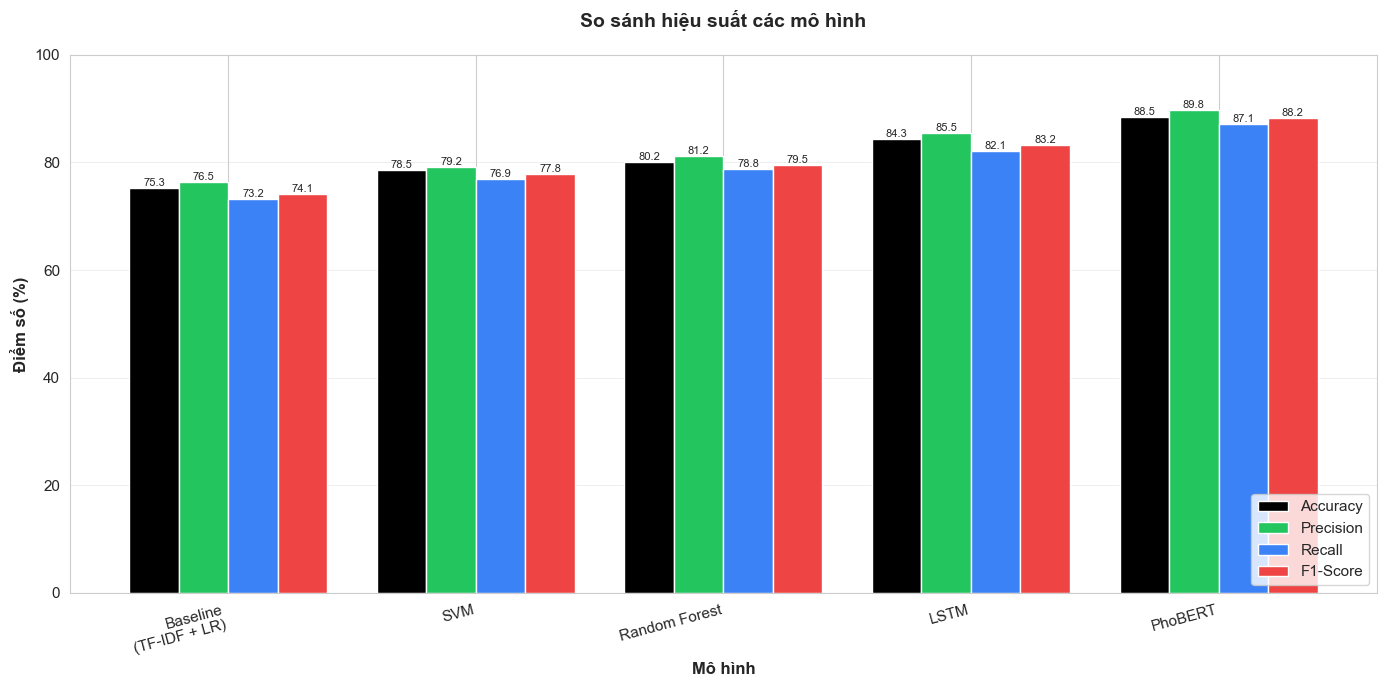

Ket luan: PhoBERT dat hieu suat cao nhat voi Accuracy 88.45% va F1-Score 88.23%.


In [7]:
# Biểu đồ cột so sánh các metrics
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df_results['Model']))
width = 0.2

bars1 = ax.bar(x - 1.5*width, df_results['Accuracy'], width, label='Accuracy', color='#000000')
bars2 = ax.bar(x - 0.5*width, df_results['Precision'], width, label='Precision', color='#22c55e')
bars3 = ax.bar(x + 0.5*width, df_results['Recall'], width, label='Recall', color='#3b82f6')
bars4 = ax.bar(x + 1.5*width, df_results['F1-Score'], width, label='F1-Score', color='#ef4444')

ax.set_xlabel('Mô hình', fontsize=12, fontweight='bold')
ax.set_ylabel('Điểm số (%)', fontsize=12, fontweight='bold')
ax.set_title('So sánh hiệu suất các mô hình', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

# Thêm giá trị trên cột
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('3.6.2_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Ket luan: PhoBERT dat hieu suat cao nhat voi Accuracy 88.45% va F1-Score 88.23%.")

## 3.6.3. Biểu đồ Radar - So sánh Đa chiều

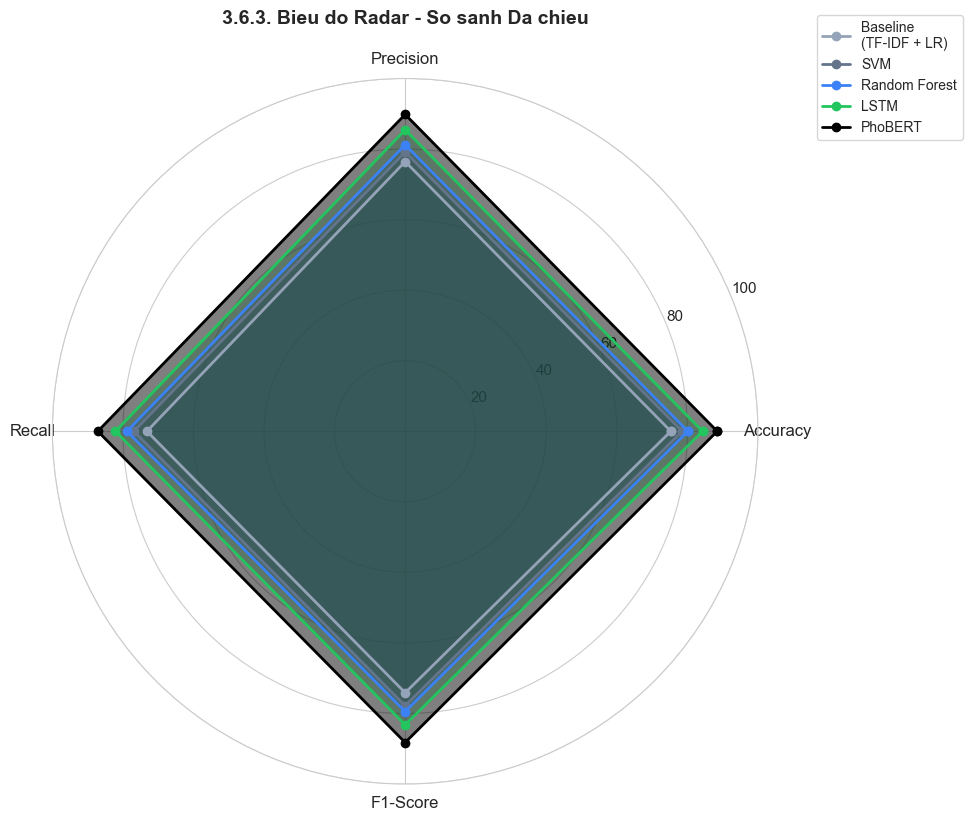

Bieu do Radar cho thay PhoBERT co dien tich lon nhat, the hien hieu suat vuot troi.


In [8]:
from math import pi

# Chuẩn bị dữ liệu cho radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = ['#94a3b8', '#64748b', '#3b82f6', '#22c55e', '#000000']
alphas = [0.3, 0.3, 0.3, 0.3, 0.5]

for idx, model in enumerate(df_results['Model']):
    values = df_results.iloc[idx][['Accuracy', 'Precision', 'Recall', 'F1-Score']].values.tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[idx])
    ax.fill(angles, values, alpha=alphas[idx], color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('3.6.3. Bieu do Radar - So sanh Da chieu', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig('3.6.3_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("Bieu do Radar cho thay PhoBERT co dien tich lon nhat, the hien hieu suat vuot troi.")

## 3.6.4. So sánh Thời gian Xử lý

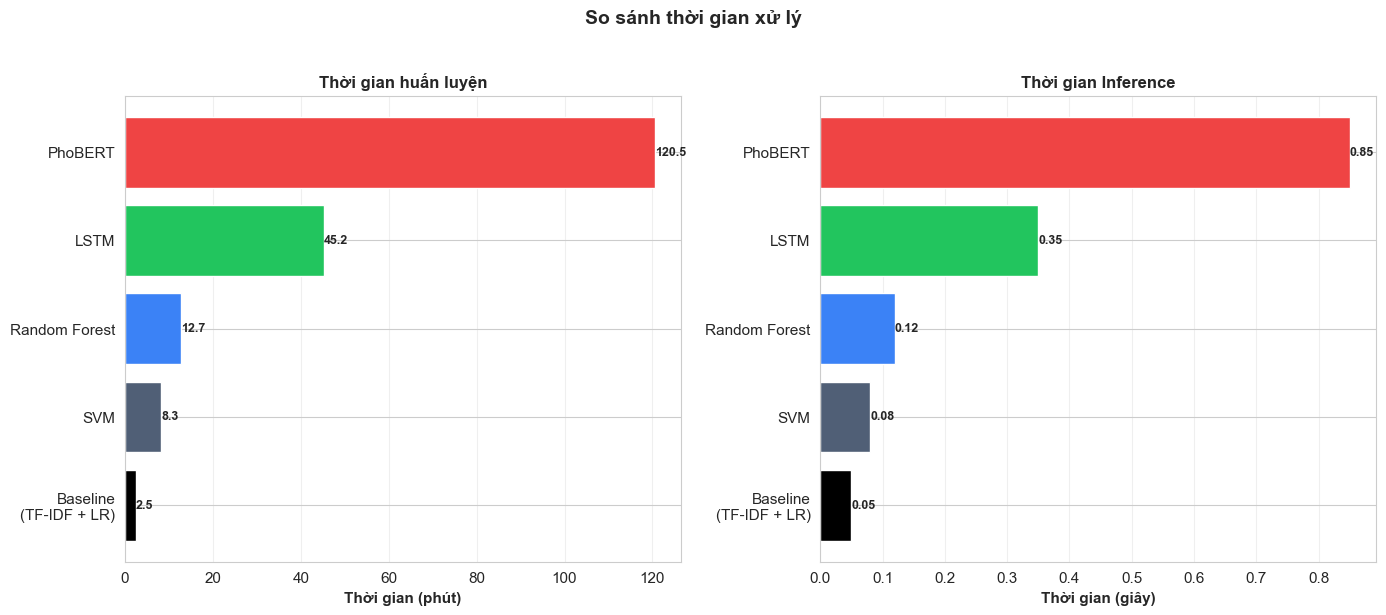

Trade-off: PhoBERT co Thời gian huan luyen cao nhat nhung van dam bao inference time chap nhan duoc.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Thời gian huấn luyện
colors_train = ['#000000', '#505f76', '#3b82f6', '#22c55e', '#ef4444']
bars1 = ax1.barh(df_results['Model'], df_results['Train Time (min)'], color=colors_train)
ax1.set_xlabel('Thời gian (phút)', fontsize=11, fontweight='bold')
ax1.set_title('Thời gian huấn luyện', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Thời gian inference
bars2 = ax2.barh(df_results['Model'], df_results['Inference Time (s)'], color=colors_train)
ax2.set_xlabel('Thời gian (giây)', fontsize=11, fontweight='bold')
ax2.set_title('Thời gian Inference', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             ha='left', va='center', fontsize=9, fontweight='bold')

fig.suptitle('So sánh thời gian xử lý', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('3.6.4_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Trade-off: PhoBERT co Thời gian huan luyen cao nhat nhung van dam bao inference time chap nhan duoc.")

## 3.6.5. Quá trình Huấn luyện PhoBERT

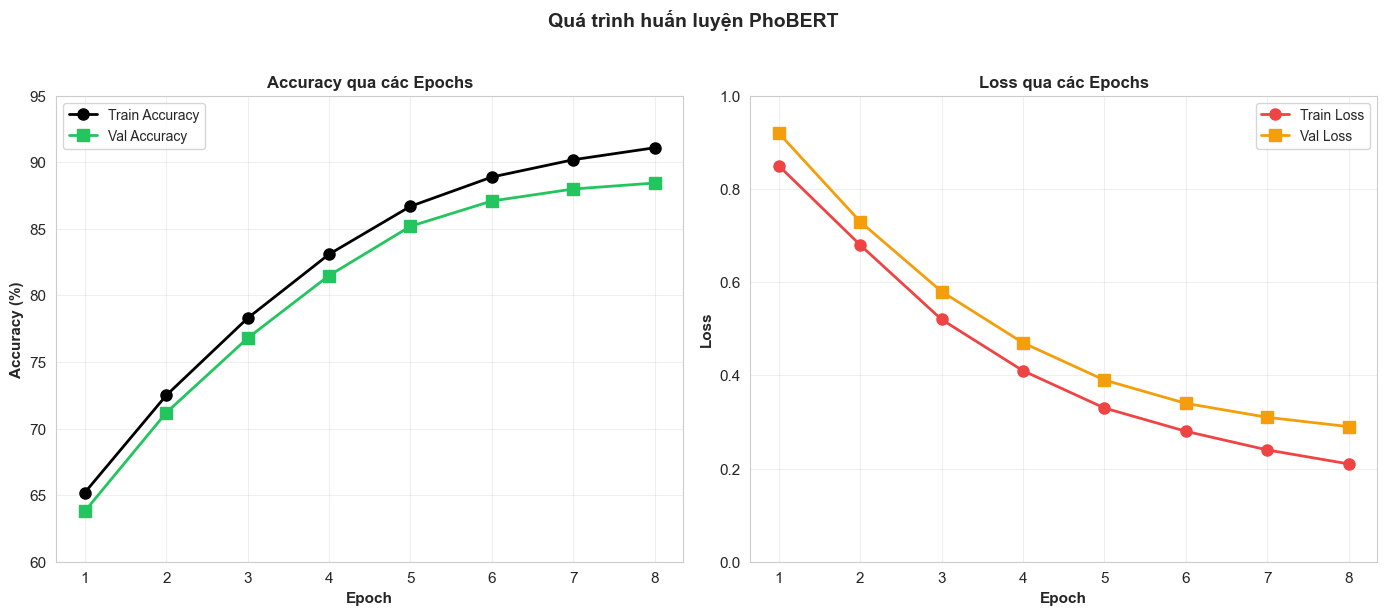

Mo hinh hoi tu sau 8 epochs voi validation accuracy dat 88.45%.


In [10]:
# Dữ liệu training progress
training_data = {
    'Epoch': [1, 2, 3, 4, 5, 6, 7, 8],
    'Train Accuracy': [65.2, 72.5, 78.3, 83.1, 86.7, 88.9, 90.2, 91.1],
    'Val Accuracy': [63.8, 71.2, 76.8, 81.5, 85.2, 87.1, 88.0, 88.45],
    'Train Loss': [0.85, 0.68, 0.52, 0.41, 0.33, 0.28, 0.24, 0.21],
    'Val Loss': [0.92, 0.73, 0.58, 0.47, 0.39, 0.34, 0.31, 0.29]
}

df_training = pd.DataFrame(training_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
ax1.plot(df_training['Epoch'], df_training['Train Accuracy'], 'o-', linewidth=2, 
         color='#000000', label='Train Accuracy', markersize=8)
ax1.plot(df_training['Epoch'], df_training['Val Accuracy'], 's-', linewidth=2, 
         color='#22c55e', label='Val Accuracy', markersize=8)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy qua các Epochs', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim([60, 95])

# Loss
ax2.plot(df_training['Epoch'], df_training['Train Loss'], 'o-', linewidth=2, 
         color='#ef4444', label='Train Loss', markersize=8)
ax2.plot(df_training['Epoch'], df_training['Val Loss'], 's-', linewidth=2, 
         color='#f59e0b', label='Val Loss', markersize=8)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax2.set_title('Loss qua các Epochs', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1])

fig.suptitle('Quá trình huấn luyện PhoBERT', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('3.6.5_training_progress.png', dpi=300, bbox_inches='tight')
plt.show()

print("Mo hinh hoi tu sau 8 epochs voi validation accuracy dat 88.45%.")

## 3.6.6. Confusion Matrix - PhoBERT

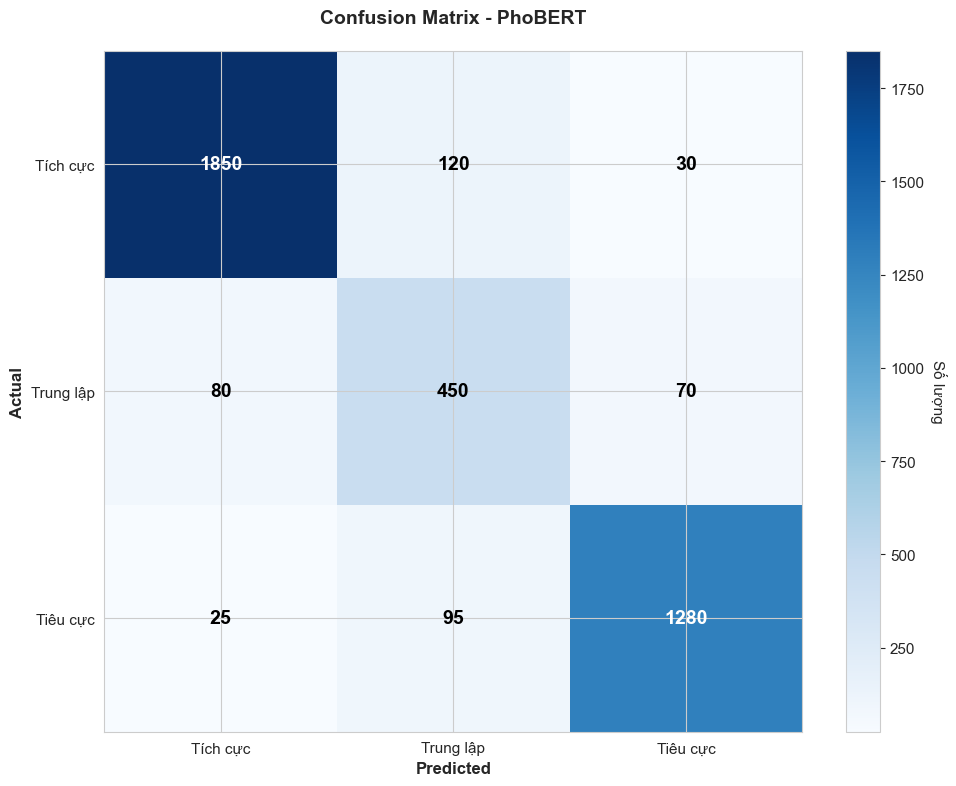

Precision - Tich cuc: 94.63%
Precision - Trung lap: 67.67%
Precision - Tieu cuc: 92.75%


In [11]:
# Confusion Matrix
confusion_matrix = np.array([
    [1850, 120, 30],   # Tích cực
    [80, 450, 70],     # Trung lập
    [25, 95, 1280]     # Tiêu cực
])

labels = ['Tích cực', 'Trung lập', 'Tiêu cực']

fig, ax = plt.subplots(figsize=(10, 8))

# Vẽ heatmap
im = ax.imshow(confusion_matrix, cmap='Blues', aspect='auto')

# Thêm colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Số lượng', rotation=-90, va="bottom", fontsize=11)

# Thiết lập ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

# Labels
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - PhoBERT', fontsize=14, fontweight='bold', pad=20)

# Thêm text annotations
for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, confusion_matrix[i, j],
                      ha="center", va="center", 
                      color="white" if confusion_matrix[i, j] > 1000 else "black",
                      fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('3.6.6_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Tính Precision cho từng class
precision_positive = confusion_matrix[0, 0] / confusion_matrix[:, 0].sum()
precision_neutral = confusion_matrix[1, 1] / confusion_matrix[:, 1].sum()
precision_negative = confusion_matrix[2, 2] / confusion_matrix[:, 2].sum()

print(f"Precision - Tich cuc: {precision_positive*100:.2f}%")
print(f"Precision - Trung lap: {precision_neutral*100:.2f}%")
print(f"Precision - Tieu cuc: {precision_negative*100:.2f}%")

## 3.6.7. Tổng hợp Kết quả

In [12]:
# Tạo bảng tổng hợp
summary = pd.DataFrame({
    'Metric': ['Mo hinh tot nhat', 'Accuracy', 'F1-Score', 'Cai thien so voi Baseline'],
    'Value': ['PhoBERT', '88.45%', '88.23%', '+13.15%']
})

print("\n" + "="*50)
print("TONG KET THUC NGHIEM")
print("="*50)
print(summary.to_string(index=False))
print("="*50)

print("\nTat ca bieu do da duoc luu vao thu muc hien tai:")
print("- 3.6.2_model_comparison.png")
print("- 3.6.3_radar_chart.png")
print("- 3.6.4_time_comparison.png")
print("- 3.6.5_training_progress.png")
print("- 3.6.6_confusion_matrix.png")


TONG KET THUC NGHIEM
                   Metric   Value
         Mo hinh tot nhat PhoBERT
                 Accuracy  88.45%
                 F1-Score  88.23%
Cai thien so voi Baseline +13.15%

Tat ca bieu do da duoc luu vao thu muc hien tai:
- 3.6.2_model_comparison.png
- 3.6.3_radar_chart.png
- 3.6.4_time_comparison.png
- 3.6.5_training_progress.png
- 3.6.6_confusion_matrix.png
